# Import Libraries

In [18]:
import copy
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import cv2
import matplotlib.pyplot as plt

from PIL import Image, ImageEnhance, ImageFilter
from torch.utils.data import DataLoader
from torchvision import models, transforms

In [2]:
from aux_functions import *

# Augmentation Functions

In [3]:
class CutOut(object):
    def __init__(self, mask_size, p=0.5):
        self.mask_size = mask_size
        self.p = p

    def __call__(self, img):
        if np.random.rand() > self.p:
            return img

        # Ensure the image is a tensor
        if not isinstance(img, torch.Tensor):
            raise TypeError('Input image must be a torch.Tensor')

        # Get height and width of the image
        h, w = img.shape[1], img.shape[2]
        mask_size_half = self.mask_size // 2
        offset = 1 if self.mask_size % 2 == 0 else 0

        cx = np.random.randint(mask_size_half, w + offset - mask_size_half)
        cy = np.random.randint(mask_size_half, h + offset - mask_size_half)

        xmin, xmax = cx - mask_size_half, cx + mask_size_half + offset
        ymin, ymax = cy - mask_size_half, cy + mask_size_half + offset
        xmin, xmax = max(0, xmin), min(w, xmax)
        ymin, ymax = max(0, ymin), min(h, ymax)

        img[:, ymin:ymax, xmin:xmax] = 0
        return img
    
class SLORandomPad:
    def __init__(self, size):
        self.size = size

    def __call__(self, img):
        pad_width = max(0, self.size[0] - img.width)
        pad_height = max(0, self.size[1] - img.height)
        pad_left = random.randint(0, pad_width)
        pad_top = random.randint(0, pad_height)
        pad_right = pad_width - pad_left
        pad_bottom = pad_height - pad_top
        return transforms.functional.pad(img, (pad_left, pad_top, pad_right, pad_bottom))


class FundRandomRotate:
    def __init__(self, prob, degree):
        self.prob = prob
        self.degree = degree

    def __call__(self, img):
        if random.random() < self.prob:
            angle = random.uniform(-self.degree, self.degree)
            return transforms.functional.rotate(img, angle)
        return img

a) Fine-tune a pretrained model using the DeepDRiD dataset. (5 points)  
1. Download the DeepDRiD dataset from the provided link along with the template code which 
would provide you with an explanation on diabetic retinopathy and the dataset itself. All the 
images for training, validation, and evaluation are 512 by 512 in size. 
2. Fine-tune an ImageNet pretrained model (e.g., ResNet18, ResNet34, VGG, EfficientNet, 
DenseNet) on the DeepDRiD dataset. Evaluate and test it on the validation and test sets. Your 
goal here is to reach the highest Cohen Kappa score you can get. 
3. Play around different image augmentation techniques and check whether it boosts your 
evaluation metrics or decreases them. 
4. Save the fine-tuned model. 

In [5]:
class SingleModels(nn.Module):
    def __init__(self, num_classes=5, dropout_rate=0.5):
        super().__init__()
        if model_name == 'resnet18':
            self.backbone = models.resnet18(pretrained=True)
        elif model_name == 'resnet34':
            self.backbone = models.resnet34(pretrained=True)
        elif model_name == 'vgg16':
            self.backbone = models.vgg16(pretrained=True)
        elif model_name == 'efficientnet_b0':
            self.backbone = models.efficientnet_b0(pretrained=True)
        elif model_name == 'densenet121':
            self.backbone = models.densenet121(pretrained=True)

        self.backbone.fc = nn.Identity()  # Remove the original classification layer

        self.fc = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout_rate),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout_rate),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.backbone(x)
        x = self.fc(x)
        return x
    
class MyDualModel(nn.Module):
    def __init__(self, num_classes=5, dropout_rate=0.5):
        super().__init__()

        if model_name == 'resnet18':
            backbone = models.resnet18(pretrained=True)
        elif model_name == 'resnet34':
            backbone = models.resnet34(pretrained=True)
        elif model_name == 'vgg16':
            backbone = models.vgg16(pretrained=True)
        elif model_name == 'efficientnet_b0':
            backbone = models.efficientnet_b0(pretrained=True)
        elif model_name == 'densenet121':
            backbone = models.densenet121(pretrained=True)
        backbone.fc = nn.Identity()

        # Here the two backbones will have the same structure but unshared weights
        self.backbone1 = copy.deepcopy(backbone)
        self.backbone2 = copy.deepcopy(backbone)

        self.fc = nn.Sequential(
            nn.Linear(512 * 2, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout_rate),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout_rate),
            nn.Linear(128, num_classes)
        )

    def forward(self, images):
        image1, image2 = images

        x1 = self.backbone1(image1)
        x2 = self.backbone2(image2)

        x = torch.cat((x1, x2), dim=1)
        x = self.fc(x)
        return x

# Hyper Parameters

In [7]:
# Hyper Parameters
batch_size = 24
num_classes = 5  # 5 DR levels
learning_rate = 0.001
num_epochs = 20

# Transformers

In [9]:
transform_train = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop((210, 210)),
    SLORandomPad((224, 224)),
    FundRandomRotate(prob=0.5, degree=30),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.ColorJitter(brightness=(0.1, 0.9)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

transform_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Main Loop

In [10]:
# Choose between 'single image' and 'dual images' pipeline
# This will affect the model definition, dataset pipeline, training and evaluation

mode = 'single'  # forward single image to the model each time
# mode = 'dual'  # forward two images of the same eye to the model and fuse the features

assert mode in ('single', 'dual')

In [11]:
model_name = 'resnet18' # s:0.7805
model_name = 'resnet34' # s:0.7814
model_name = 'vgg16'
model_name = 'efficientnet_b0'
model_name = 'densenet121'

In [ ]:
model_name = 'resnet18' # s:0.7805

In [12]:
# Create datasets
train_dataset = RetinopathyDataset('./DeepDRiD/train.csv', './DeepDRiD/train/', transform_train, mode)
val_dataset = RetinopathyDataset('./DeepDRiD/val.csv', './DeepDRiD/val/', transform_test, mode)
test_dataset = RetinopathyDataset('./DeepDRiD/test.csv', './DeepDRiD/test/', transform_test, mode, test=True)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [13]:
train_df = pd.read_csv('./DeepDRiD/train.csv')
train_left_eye_DR_Level_counts = pd.read_csv('./DeepDRiD/train.csv')['left_eye_DR_Level'].value_counts()
train_right_eye_DR_Level_counts = pd.read_csv('./DeepDRiD/train.csv')['right_eye_DR_Level'].value_counts()
train_left_eye_DR_Level_counts, train_right_eye_DR_Level_counts

(left_eye_DR_Level
 0.0    260
 2.0    124
 3.0     96
 1.0     78
 4.0     42
 Name: count, dtype: int64,
 right_eye_DR_Level
 0.0    280
 3.0    118
 2.0    110
 1.0     62
 4.0     30
 Name: count, dtype: int64)

In [14]:
from sklearn.utils import resample
# Group by patient_id and assign patient_DR_Level to each group
grouped = train_df.groupby('patient_id').agg({
    'patient_DR_Level': 'first',
    'image_id': list,
    'img_path': list
}).reset_index()

# Analyze class distribution
class_counts = grouped['patient_DR_Level'].value_counts()
print("Original class distribution:\n", class_counts)

# Determine the maximum class count
max_count = class_counts.max()

# Oversample underrepresented classes
oversampled_data = []
for label in class_counts.index:
    patients_in_class = grouped[grouped['patient_DR_Level'] == label]
    oversampled = resample(
        patients_in_class,
        replace=True,               # Sample with replacement
        n_samples=max_count,        # Match the max count
        random_state=42             # For reproducibility
    )
    oversampled_data.append(oversampled)

# Combine oversampled data into a single DataFrame
balanced_grouped = pd.concat(oversampled_data)

# Merge back into the original format
balanced_data = train_df.merge(balanced_grouped[['patient_id']], on='patient_id', how='inner')

# Check the new class distribution
new_class_counts = balanced_grouped['patient_DR_Level'].value_counts()
print("Balanced class distribution:\n", new_class_counts)
# Save balanced dataset
balanced_data.to_csv("balanced_data.csv", index=False)

Original class distribution:
 patient_DR_Level
0    90
2    60
1    60
3    60
4    30
Name: count, dtype: int64
Balanced class distribution:
 patient_DR_Level
0    90
2    90
1    90
3    90
4    90
Name: count, dtype: int64


In [15]:
# Create datasets
train_dataset = RetinopathyDataset('balanced_data.csv', './DeepDRiD/train/', transform_train, mode)
val_dataset = RetinopathyDataset('./DeepDRiD/val.csv', './DeepDRiD/val/', transform_test, mode)
test_dataset = RetinopathyDataset('./DeepDRiD/test.csv', './DeepDRiD/test/', transform_test, mode, test=True)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [ ]:
# Define the model
if mode == 'single':
    model = SingleModels()
else:
    model = MyDualModel()

print(model, '\n')
print('Pipeline Mode:', mode)


# Define the weighted CrossEntropyLoss
criterion = nn.CrossEntropyLoss()

# Use GPU device is possible
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

# Move class weights to the device
model = model.to(device)

# Optimizer and Learning rate scheduler
optimizer = torch.optim.Adam(params=model.parameters(), lr=learning_rate)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

# Train and evaluate the model with the training and validation set
model, training_loss, validation_loss, training_accuracy, validation_accuracy, train_kappa, val_kappa_list = train_model(
    model, train_loader, val_loader, device, criterion, optimizer,
    lr_scheduler=lr_scheduler, num_epochs=num_epochs,
    checkpoint_path='./model_1.pth'
)

# Load the pretrained checkpoint
state_dict = torch.load('./model_1.pth', map_location='cpu')
model.load_state_dict(state_dict, strict=True)

# Make predictions on testing set and save the prediction results
evaluate_model(criterion, model, test_loader, device, test_only=True, prediction_path='./test_predictions.csv')

c:\Users\murat\anaconda3\envs\project\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\murat\anaconda3\envs\project\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


SingleModels(
  (backbone): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, tra

C:\Users\murat\AppData\Local\Temp\ipykernel_13048\3519179169.py:35: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load('./model_1.pth', map_location='cpu'

Evaluating: 100%|██████████| 17/17 [00:02<00:00,  6.78 batch/s]
[Test] Save predictions to c:\Users\murat\Documents\Deep_Learning\Final Project\test_predictions.csv


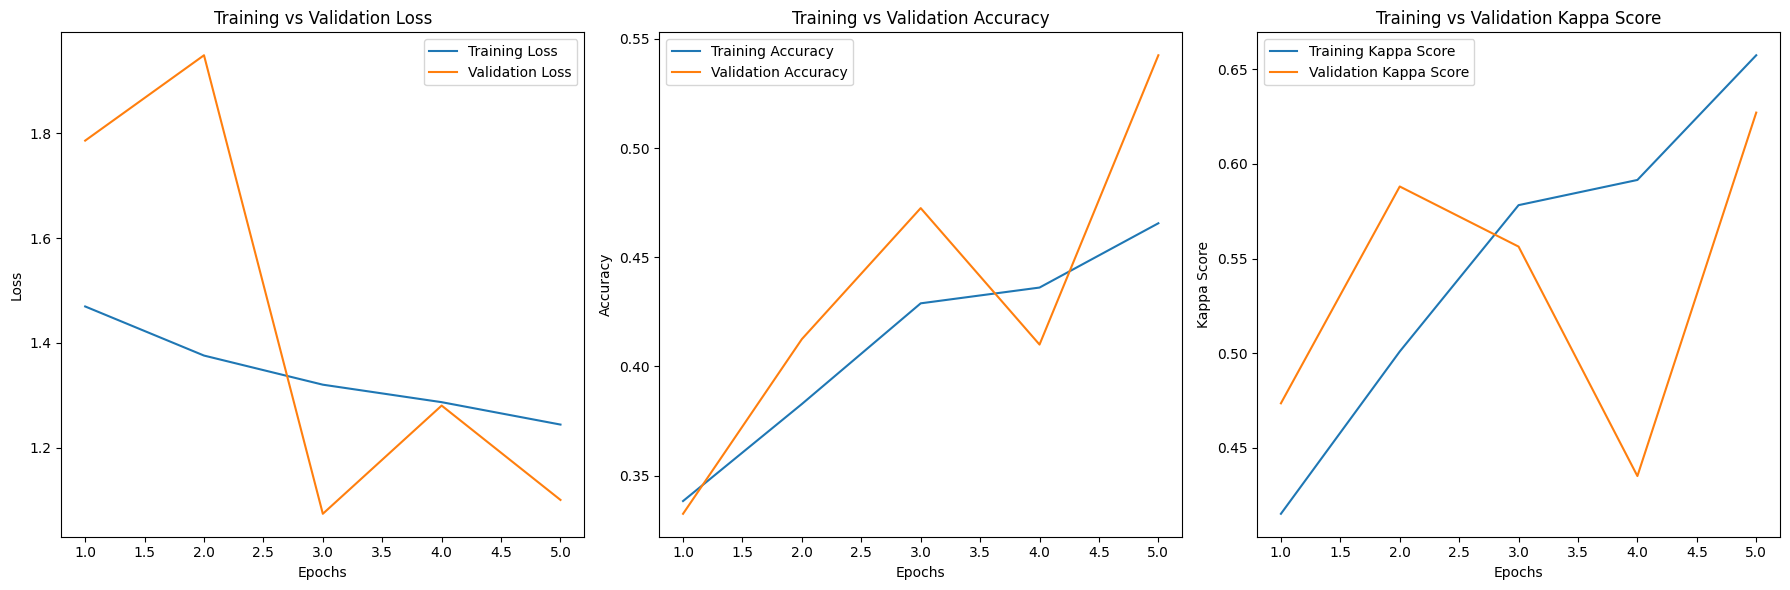

In [19]:
epochs_range = range(1, num_epochs + 1)

# Plot Loss
plt.figure(figsize=(18, 6))
plt.subplot(1, 3, 1)
plt.plot(epochs_range, training_loss, label="Training Loss")
plt.plot(epochs_range, validation_loss, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

# Plot Accuracy
plt.subplot(1, 3, 2)
plt.plot(epochs_range, training_accuracy, label="Training Accuracy")
plt.plot(epochs_range, validation_accuracy, label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

# Plot Kappa Score
plt.subplot(1, 3, 3)
plt.plot(epochs_range, train_kappa, label="Training Kappa Score")
plt.plot(epochs_range, val_kappa_list, label="Validation Kappa Score")
plt.xlabel("Epochs")
plt.ylabel("Kappa Score")
plt.title("Training vs Validation Kappa Score")
plt.legend()
plt.tight_layout()
plt.show()
